In [8]:
!pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 7.3 MB/s eta 0:00:00


In [1]:
import pandas as pd

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00242/ENB2012_data.xlsx"
df = pd.read_excel(url)
df.columns = [
    'relative_compactness', 'surface_area', 'wall_area', 'roof_area',
    'overall_height', 'orientation', 'glazing_area', 'glazing_distribution',
    'heating_load', 'cooling_load'
]
df.head()

,relative_compactness,surface_area,wall_area,roof_area,overall_height,orientation,glazing_area,glazing_distribution,heating_load,cooling_load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


Exploaring the data


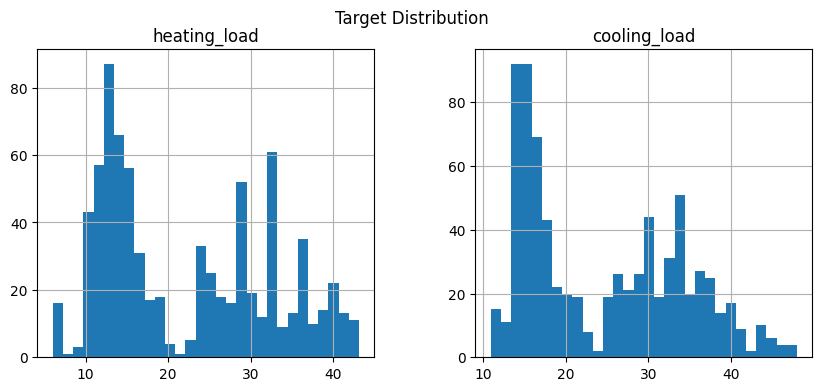

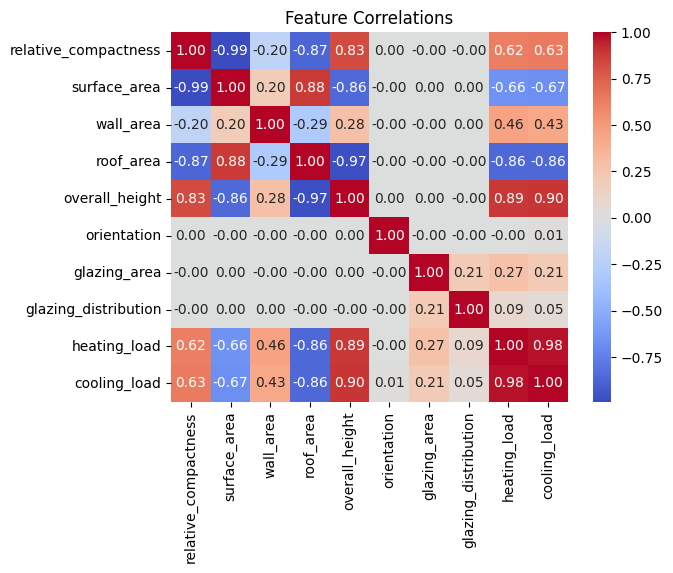

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of targets
df[['heating_load', 'cooling_load']].hist(bins=30, figsize=(10, 4))
plt.suptitle("Target Distribution")
plt.show()

# Correlation heatmap
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlations")
plt.show()

Feature Engineering

In [3]:
# Glazing ratio (glazing area relative to surface)
df['glazing_ratio'] = df['glazing_area'] / df['surface_area']

# Volume proxy
df['volume_proxy'] = df['surface_area'] * df['overall_height']

# Wall-to-surface ratio (insulation proxy)
df['wall_surface_ratio'] = df['wall_area'] / df['surface_area']

Model Training

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

features = ['relative_compactness', 'surface_area', 'wall_area', 'roof_area',
            'overall_height', 'orientation', 'glazing_area', 'glazing_distribution',
            'glazing_ratio', 'volume_proxy', 'wall_surface_ratio']

X = df[features]
y_heat = df['heating_load']
y_cool = df['cooling_load']

X_train, X_test, yh_train, yh_test = train_test_split(X, y_heat, test_size=0.2, random_state=42)
_, _, yc_train, yc_test = train_test_split(X, y_cool, test_size=0.2, random_state=42)

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, yh_train)
    preds = model.predict(X_test)
    mae = mean_absolute_error(yh_test, preds)
    rmse = np.sqrt(mean_squared_error(yh_test, preds))
    results[name] = {"MAE": round(mae, 3), "RMSE": round(rmse, 3)}

print(pd.DataFrame(results).T)

                     MAE   RMSE
Linear Regression  1.895  2.383
Random Forest      0.343  0.471
XGBoost            0.234  0.357


Hyperparameter Tuning

In [7]:
import optuna

ModuleNotFoundError: No module named 'optuna'

In [9]:
import optuna

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0)
    }
    model = XGBRegressor(**params, random_state=42)
    model.fit(X_train, yh_train)
    preds = model.predict(X_test)
    return mean_absolute_error(yh_test, preds)

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)
print("Best params:", study.best_params)

[I 2026-04-24 14:13:40,116] A new study created in memory with name: no-name-62b0aa7b-cf2f-4980-8a04-599b9f39dce4
[I 2026-04-24 14:13:42,158] Trial 0 finished with value: 0.2760083753164713 and parameters: {'n_estimators': 181, 'max_depth': 5, 'learning_rate': 0.14576767493492215, 'subsample': 0.6367926427870937}. Best is trial 0 with value: 0.2760083753164713.
[I 2026-04-24 14:13:42,569] Trial 1 finished with value: 0.30138390394929176 and parameters: {'n_estimators': 99, 'max_depth': 8, 'learning_rate': 0.05903361195958499, 'subsample': 0.7666074159853933}. Best is trial 0 with value: 0.2760083753164713.
[I 2026-04-24 14:13:42,751] Trial 2 finished with value: 0.26903178274476675 and parameters: {'n_estimators': 53, 'max_depth': 10, 'learning_rate': 0.1872487521917345, 'subsample': 0.6234744720880384}. Best is trial 2 with value: 0.26903178274476675.
[I 2026-04-24 14:13:42,895] Trial 3 finished with value: 0.2787053666548295 and parameters: {'n_estimators': 127, 'max_depth': 5, 'lear

Best params: {'n_estimators': 203, 'max_depth': 7, 'learning_rate': 0.2698418154344944, 'subsample': 0.8822951195731429}


Shap Explainibality

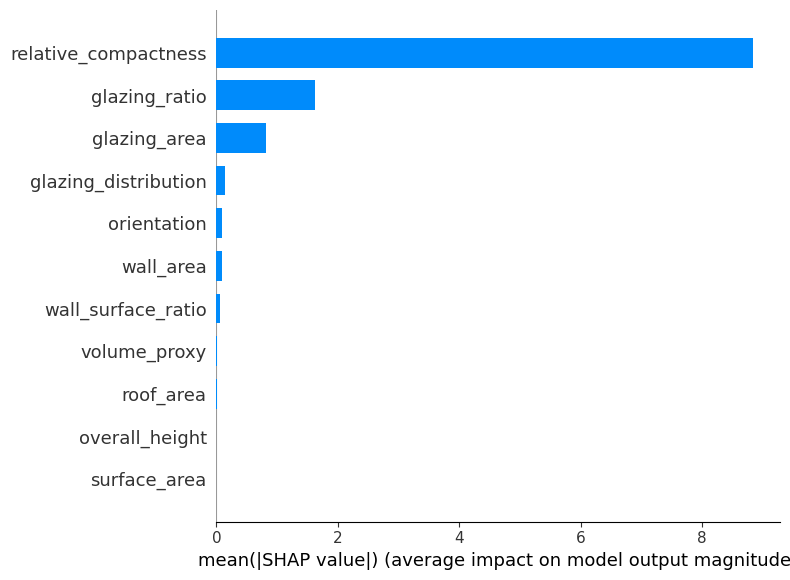

In [10]:
import shap

best_model = XGBRegressor(**study.best_params, random_state=42)
best_model.fit(X_train, yh_train)

explainer = shap.Explainer(best_model)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test, plot_type="bar",
                  title="Which Building Features Drive Energy Load?")

Energy Class Labelling

In [11]:
def energy_class(load):
    if load < 10: return 'A (Excellent)'
    elif load < 20: return 'B (Good)'
    elif load < 30: return 'C (Average)'
    elif load < 40: return 'D (Below Average)'
    else: return 'E (Poor — Retrofit Needed)'

df['energy_class'] = df['heating_load'].apply(energy_class)

Streamlit Dashboard

In [15]:
app_code = """
import streamlit as st

st.title("🏢 Building Energy Efficiency Predictor")
st.markdown("Predict heating load and energy class for any building.")

st.sidebar.header("Building Parameters")
compactness = st.sidebar.slider("Relative Compactness", 0.62, 0.98, 0.75)
surface_area = st.sidebar.slider("Surface Area (m²)", 514.0, 808.0, 660.0)
wall_area = st.sidebar.slider("Wall Area (m²)", 245.0, 416.5, 318.0)
height = st.sidebar.slider("Overall Height (m)", 3.5, 7.0, 5.25)
glazing_area = st.sidebar.slider("Glazing Area", 0.0, 0.4, 0.1)

def energy_class(load):
    if load < 10: return 'A ✅ Excellent'
    elif load < 20: return 'B 🟢 Good'
    elif load < 30: return 'C 🟡 Average'
    elif load < 40: return 'D 🟠 Below Average'
    else: return 'E 🔴 Poor — Retrofit Needed!'

st.info("Add your model prediction here once trained.")
"""

with open("app.py", "w") as f:
    f.write(app_code)

print("✅ app.py written!")

✅ app.py written!


In [18]:
# Install dependencies
!pip install streamlit pyngrok -q

# Set your ngrok authtoken — paste YOUR token here
from pyngrok import ngrok
ngrok.set_auth_token("3CGJcctOdtDEZfQLddZwQbb3fyU_6ygtH3cznzR1PN4biiAsi")

# Run Streamlit in background
import subprocess
import threading
import time

def run_streamlit():
    subprocess.Popen([
        "streamlit", "run", "app.py",
        "--server.port", "8501",
        "--server.headless", "true"
    ])

threading.Thread(target=run_streamlit).start()
time.sleep(5)  # Wait for Streamlit to start

# Create public tunnel
public_url = ngrok.connect(8501)
print(f"\n✅ Your app is live at: {public_url}")


✅ Your app is live at: NgrokTunnel: "https://repackage-headwear-vascular.ngrok-free.dev" -> "http://localhost:8501"


In [19]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from xgboost import XGBRegressor
import optuna
import pickle

# Load dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00242/ENB2012_data.xlsx"
df = pd.read_excel(url)
df.columns = [
    'relative_compactness', 'surface_area', 'wall_area', 'roof_area',
    'overall_height', 'orientation', 'glazing_area', 'glazing_distribution',
    'heating_load', 'cooling_load'
]

# Feature engineering
df['glazing_ratio'] = df['glazing_area'] / df['surface_area']
df['volume_proxy'] = df['surface_area'] * df['overall_height']
df['wall_surface_ratio'] = df['wall_area'] / df['surface_area']

# Define features & target
features = ['relative_compactness', 'surface_area', 'wall_area', 'roof_area',
            'overall_height', 'orientation', 'glazing_area', 'glazing_distribution',
            'glazing_ratio', 'volume_proxy', 'wall_surface_ratio']

X = df[features]
y = df['heating_load']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Optuna tuning
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0)
    }
    model = XGBRegressor(**params, random_state=42)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return mean_absolute_error(y_test, preds)

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)
print("✅ Best MAE:", round(study.best_value, 3))
print("✅ Best params:", study.best_params)

# Train final model with best params
best_model = XGBRegressor(**study.best_params, random_state=42)
best_model.fit(X_train, y_train)

# Save model
with open("model.pkl", "wb") as f:
    pickle.dump(best_model, f)

print("✅ model.pkl saved!")

✅ Best MAE: 0.238
✅ Best params: {'n_estimators': 255, 'max_depth': 9, 'learning_rate': 0.255967377659578, 'subsample': 0.8968367615230453}
✅ model.pkl saved!


In [20]:
app_code = """
import streamlit as st
import pandas as pd
import numpy as np
import pickle

with open("model.pkl", "rb") as f:
    model = pickle.load(f)

st.title("🏢 Building Energy Efficiency Predictor")
st.markdown("Predict heating load and energy class for any building.")

st.sidebar.header("Building Parameters")
compactness = st.sidebar.slider("Relative Compactness", 0.62, 0.98, 0.75)
surface_area = st.sidebar.slider("Surface Area (m²)", 514.0, 808.0, 660.0)
wall_area = st.sidebar.slider("Wall Area (m²)", 245.0, 416.5, 318.0)
roof_area = st.sidebar.slider("Roof Area (m²)", 110.0, 220.0, 147.0)
height = st.sidebar.slider("Overall Height (m)", 3.5, 7.0, 5.25)
glazing_area = st.sidebar.slider("Glazing Area", 0.0, 0.4, 0.1)
orientation = st.sidebar.selectbox("Orientation", [2, 3, 4, 5])
glazing_dist = st.sidebar.selectbox("Glazing Distribution", [0, 1, 2, 3, 4, 5])

glazing_ratio = glazing_area / surface_area
volume_proxy = surface_area * height
wall_surface_ratio = wall_area / surface_area

def energy_class(load):
    if load < 10: return 'A ✅ Excellent'
    elif load < 20: return 'B 🟢 Good'
    elif load < 30: return 'C 🟡 Average'
    elif load < 40: return 'D 🟠 Below Average'
    else: return 'E 🔴 Poor — Retrofit Needed!'

features = ['relative_compactness','surface_area','wall_area','roof_area',
            'overall_height','orientation','glazing_area','glazing_distribution',
            'glazing_ratio','volume_proxy','wall_surface_ratio']

input_data = pd.DataFrame([[compactness, surface_area, wall_area, roof_area,
                            height, orientation, glazing_area, glazing_dist,
                            glazing_ratio, volume_proxy, wall_surface_ratio]],
                          columns=features)

if st.button("🔍 Predict Energy Load"):
    pred = model.predict(input_data)[0]
    label = energy_class(pred)
    col1, col2 = st.columns(2)
    col1.metric("Heating Load", f"{pred:.2f} kWh/m²")
    col2.metric("Energy Class", label)
    if pred > 30:
        st.warning("⚠️ This building is a strong candidate for energy retrofit!")
    else:
        st.balloons()
        st.success("✅ This building has good energy performance!")
"""

with open("app.py", "w") as f:
    f.write(app_code)

print("✅ app.py updated with model!")

✅ app.py updated with model!


In [21]:
import subprocess, threading, time
from pyngrok import ngrok

# Kill existing tunnels and restart
ngrok.kill()

# Restart Streamlit
def run_streamlit():
    subprocess.Popen([
        "streamlit", "run", "app.py",
        "--server.port", "8502",
        "--server.headless", "true"
    ])

threading.Thread(target=run_streamlit).start()
time.sleep(5)

# New tunnel
public_url = ngrok.connect(8502)
print(f"\n✅ Updated app is live at: {public_url}")


✅ Updated app is live at: NgrokTunnel: "https://repackage-headwear-vascular.ngrok-free.dev" -> "http://localhost:8502"


In [22]:
from google.colab import files

# Download model
files.download("model.pkl")

# Download app
files.download("app.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>